# Cora – GCN vs GAT
This notebook **visualizes** results only.  
All training logic lives in `experiment.py`. Run the study first:
```bash
python experiment.py
```
That produces `results.csv`, which the cells below load and plot.

In [ ]:
%%capture
!pip install torch-geometric certifi scipy scikit-learn pandas matplotlib ipywidgets

In [1]:
# Run the full multi-seed study from here if you prefer not to use the terminal.
# Skip this cell if results.csv already exists.
from experiment import run_experiment, summarize
df = run_experiment()
print(summarize(df))

  GCN  seed=0 ...
  GCN  seed=1 ...
  GCN  seed=2 ...
  GCN  seed=3 ...
  GCN  seed=4 ...
  GAT  seed=0 ...
  GAT  seed=1 ...
  GAT  seed=2 ...
  GAT  seed=3 ...
  GAT  seed=4 ...

Saved 2000 rows → results.csv
         mean     std  runs
model                      
GAT    0.8172  0.0073     5
GCN    0.8134  0.0094     5


In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results.csv")

In [3]:
from experiment import summarize
summarize(df)

,mean,std,runs
model,,,
GAT,0.8172,0.0073,5
GCN,0.8134,0.0094,5


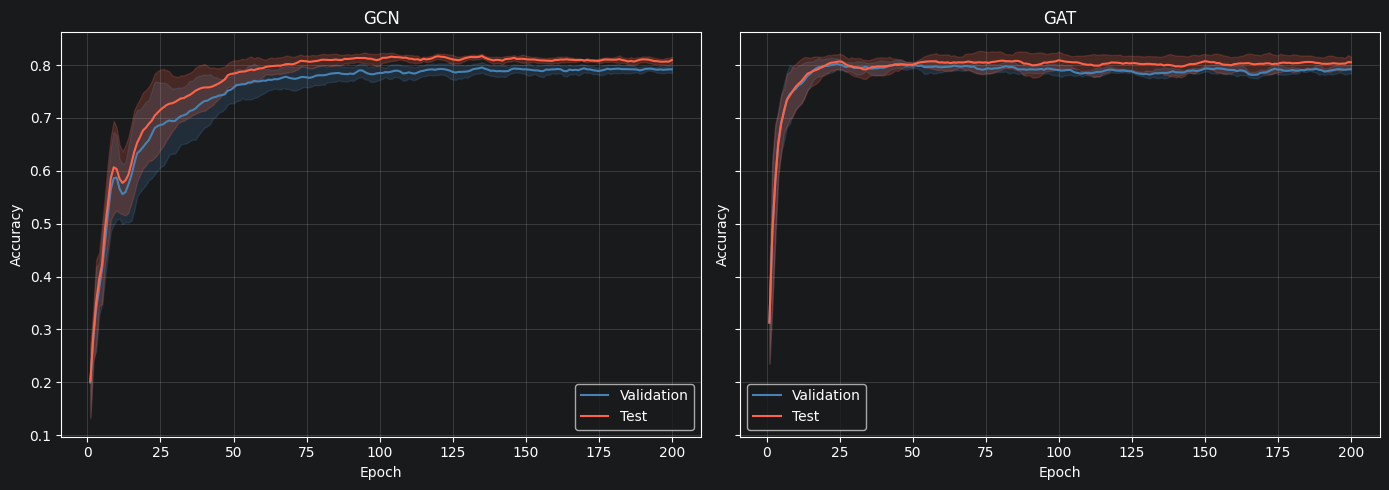

In [4]:
# Mean ± std learning curves across seeds for each model.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, model_name in zip(axes, ["GCN", "GAT"]):
    subset = df[df["model"] == model_name]

    for metric, color, label in [
        ("val_acc",  "steelblue", "Validation"),
        ("test_acc", "tomato",    "Test"),
    ]:
        # Pivot to (epoch × seed), then take mean and std across seeds.
        pivot = subset.pivot(index="epoch", columns="seed", values=metric)
        mean  = pivot.mean(axis=1)
        std   = pivot.std(axis=1)
        epochs = mean.index

        ax.plot(epochs, mean, color=color, label=label)
        ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color=color)

    ax.set_title(model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()

In [ ]:
# t-SNE of final node embeddings (seed 0, both models).
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from experiment import MODEL_CONFIGS, set_seed, data

def get_embeddings(model_name: str, seed: int = 0, epochs: int = 200):
    """Re-train with a fixed seed and return final logits for t-SNE."""
    set_seed(seed)
    cfg   = MODEL_CONFIGS[model_name]
    model = cfg["build"]()
    opt   = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    crit  = torch.nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = crit(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        opt.step()

    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    return out

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model_name in zip(axes, ["GCN", "GAT"]):
    print(f"Computing embeddings for {model_name}...")
    emb    = get_embeddings(model_name).numpy()
    labels = data.y.numpy()
    z      = TSNE(n_components=2, random_state=0).fit_transform(emb)

    sc = ax.scatter(z[:, 0], z[:, 1], c=labels, cmap="Set2", s=15, alpha=0.8)
    ax.set_title(f"{model_name} – t-SNE")
    ax.set_xticks([])
    ax.set_yticks([])

plt.colorbar(sc, ax=axes, label="Class")
plt.savefig("tsne.png", dpi=150)
plt.show()